# DS-ROM for 2D Burgers

Test smooth POD-ROM on Burgers data (no gridding). Load validation data, form train/test split, then run hyperparameter optimization (sigma, sigmaD, num_iter).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp
from cupyx.scipy.ndimage import gaussian_filter as gaussian_filter_gpu
from ezyrb import POD, Database, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from smooth_POD_ROM.post_processing import get_sigma, richardson_lucy2_gpu
from smooth_POD_ROM.reduced_order_model import (
    train_ROM_rw,
    get_predictions_gpu,
    get_improvement,
    L2_error_rw,
)
from scipy.optimize import minimize, Bounds, direct
from datetime import datetime

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.colormaps.get_cmap("plasma")
single_column = 90  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
fw, fh = single_column_in, single_column_in/1.618
single_column_figure = (fw, fh)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

In [3]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Burger/"

X_val_all = np.load(pth + "X_val.npy").T
mu_val_all = np.load(pth + "mu_val.npy")[:, None]

shape = (257, 257)
x = y = np.linspace(0, 1, 257, endpoint=True)
dx = x[1] - x[0]
sigma, c = 0.003972, 0.9349  # 3.1*dx, 1

# Train: every 19th snapshot; layout (n_train, n_dof) for train_ROM_rw
rank = 10

def split_train_test_val(X_val_all, mu_val_all, rank):
    jj = int(np.ceil(len(mu_val_all)/rank))
    X_train = X_val_all[::jj]
    mu_train = mu_val_all[::jj, :]
    print(mu_train.shape, X_train.shape, mu_train[[0, -1], :].ravel())
    # Restrict validation to mu <= max(mu_train)
    is_inside = mu_val_all[:, 0] <= mu_train[-1, 0]
    mu_val = mu_val_all[is_inside]
    X_val = X_val_all[is_inside]
    # Test: 20 random snapshots (constant seed)
    rng = np.random.default_rng(42)
    n_test_want = 20
    n_avail = len(mu_val)
    inds = rng.choice(n_avail, size=min(n_test_want, n_avail), replace=False)
    mu_test = mu_val_all[inds]
    X_test = X_val_all[inds]
    return X_train, mu_train, X_val, mu_val, X_test, mu_test

X_train, mu_train, X_val, mu_val, X_test, mu_test = split_train_test_val(X_val_all, mu_val_all, rank)
print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
print(X_train.shape, X_test.shape, X_val.shape)
print(mu_train.shape, mu_test.shape, mu_val.shape)

rank = len(mu_train)

(10, 1) (10, 66049) [0.  0.9]
(20, 1) (20, 66049) [0.683 0.469]
(10, 66049) (20, 66049) (901, 66049)
(10, 1) (20, 1) (901, 1)


In [4]:
X_grid = np.asarray(x)
Y_grid = np.asarray(y)
X_mesh, Y_mesh = np.meshgrid(X_grid, Y_grid, indexing="ij")

## Mean of training set

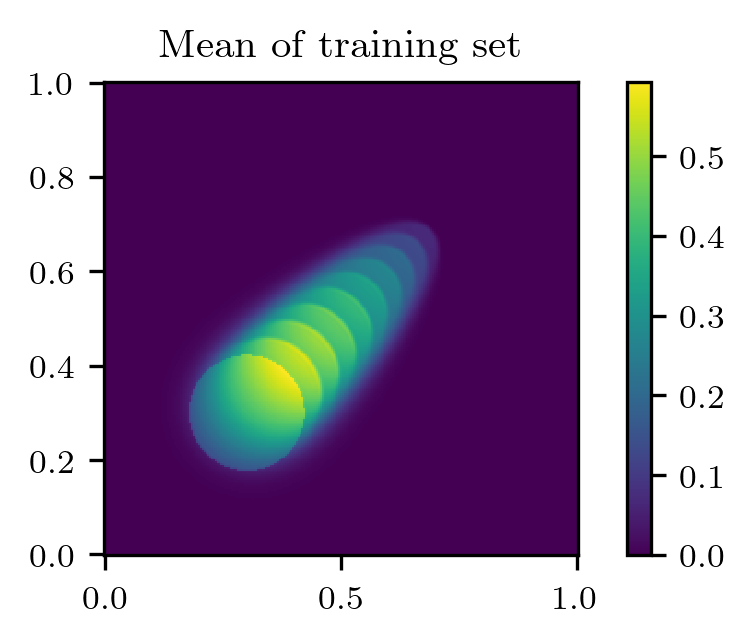

In [5]:
mean_train = np.mean(X_train, axis=0).reshape(shape)

fig, ax = plt.subplots()
cs = ax.pcolormesh(X_mesh, Y_mesh, mean_train)
plt.colorbar(cs, ax=ax)
ax.set_title("Mean of training set")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Case dict and target function

Precomputed `X_train_n`, `X_test_n` (normalized); we smooth training data on GPU and use `get_predictions_gpu` (RL deconvolution uses `richardson_lucy2_gpu`).

In [6]:
n_test = X_test.shape[0]
case = {
    "sigma": 0.01628,
    "c": 0.5617,
    "num_iter": 20,
    "shape": shape,
    "x": x,
    "dx": dx,
    "mode": "reflect",
    "sigmaD": "calc_based_on_distance",
    "mu_train": mu_train,
    "mu_test": mu_test,
    "n_test": n_test,
    "rank": rank
}


def smoothen_GPU(X_train_gpu, shape, sgm, mode):
    #X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    m0 = cp.sum(X_train_gpu, axis=(1, 2), keepdims=True)
    out = gaussian_filter_gpu(X_train_gpu, sigma=(0, sgm, sgm), truncate=8, mode=mode)
    m1 = cp.sum(out, axis=(1, 2), keepdims=True)
    out = out * cp.where(m1 > 0, m0 / m1, 1.0)
    X_train_s = cp.asnumpy(out).reshape(len(X_train_gpu), -1)
    return X_train_s


def target_function(case, X_train_gpu, mu_, u_max, X_e=None):
    sgm = case["sigma"] / case["dx"]
    mode = case["mode"]
    shape = case["shape"]
    mu_train = case["mu_train"]
    print(len(mu_train), len(mu_), case["sigma"], case["c"], case["sigmaD"][0], case["num_iter"], end=" ")
    X_train_s = smoothen_GPU(X_train_gpu, shape, sgm, mode)
    #print(mu_train.shape, X_train.shape, X_train.shape)
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    X___ROM = my_ROM.predict(mu_).snapshots_matrix

    #u_max = np.interp(mu_, mu_train.ravel(), X_train.max(axis=1)).ravel()
    #u_max = np.ones_like(mu_).ravel()*np.max(X_train)
    t1 = datetime.now()
    X___sROM, X___sROMs = get_predictions_gpu(my_sROM, mu_, cmax=u_max, **case)
    t2 = datetime.now()

    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_e, X___ROM, X___sROM, X___sROMs, norm=L2_error_rw, scaler=False
    )
    print(mean_ROM, mean_sROM, mean_sROMs, (t2-t1).total_seconds(), improvement)
    return mean_ROM, mean_sROM, mean_sROMs, X___ROM, X___sROM, X___sROMs

In [7]:
u_max = np.interp(mu_test, mu_train.ravel(), X_train.max(axis=1)).ravel()
#u_max = np.ones_like(mu_train).ravel()*np.max(X_train)
X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
mean_ROM, mean_sROM, mean_sROMs, X_test_ROM, X_test_sROM, X_test_sROMs = target_function(case, X_train_gpu, mu_test, u_max, X_e=X_test)
e_ROM = L2_error_rw(X_test_ROM, X_test)
e_sROM = L2_error_rw(X_test_sROM, X_test)
e_sROMs = L2_error_rw(X_test_sROMs, X_test)

for i in range(len(e_ROM)):
    sgm_est = get_sigma(case["sigma"], mu_test[i][None, ...], mu_train, c=case["c"])
    print(i,mu_test[i], u_max[i], np.max(X_test[i]), np.max(X_test_sROMs[i]), sgm_est, e_ROM[i], e_sROM[i], e_sROMs[i], 100 * e_sROMs[i] / e_ROM[i] - 100)

10 20 0.01628 0.5617 c 20 0.02448297424782154 0.027707092380334412 0.018587839910671526 2.030891 -24.07850564836727
0 [0.683] 0.8245252558712098 0.8161895452675378 0.8052679 0.01783456092 0.014019341400138283 0.020319035919349464 0.008913939690206247 -36.416844159895255
1 [0.642] 0.8570136220036287 0.8494035892741593 0.84383094 0.02012067992 0.024330654920913786 0.023975453285560566 0.01975070114510256 -18.823799814260056
2 [0.179] 1.1156509091055018 1.1162757203726565 1.0733333 0.01820033996 0.036944488261826364 0.036818705779324896 0.023845217189028798 -35.45663152772006
3 [0.871] 0.7118438092890775 0.7077561970058747 0.6897532 0.018931898040000002 0.01370841275870343 0.01745155050064464 0.008535592694545256 -37.73463897834536
4 [0.755] 0.7764175472709828 0.7742254569117398 0.77641755 0.020395014200000006 0.01991212625967841 0.0207731040515985 0.014454178684101865 -27.410169584092884
5 [0.681] 0.8261100542191328 0.82206847966415 0.7938871 0.01801745044 0.015271860711091127 0.02066526

8 0.021220831972158048 0.024294480167646584 0.024294480167646584 -39.350598814340465


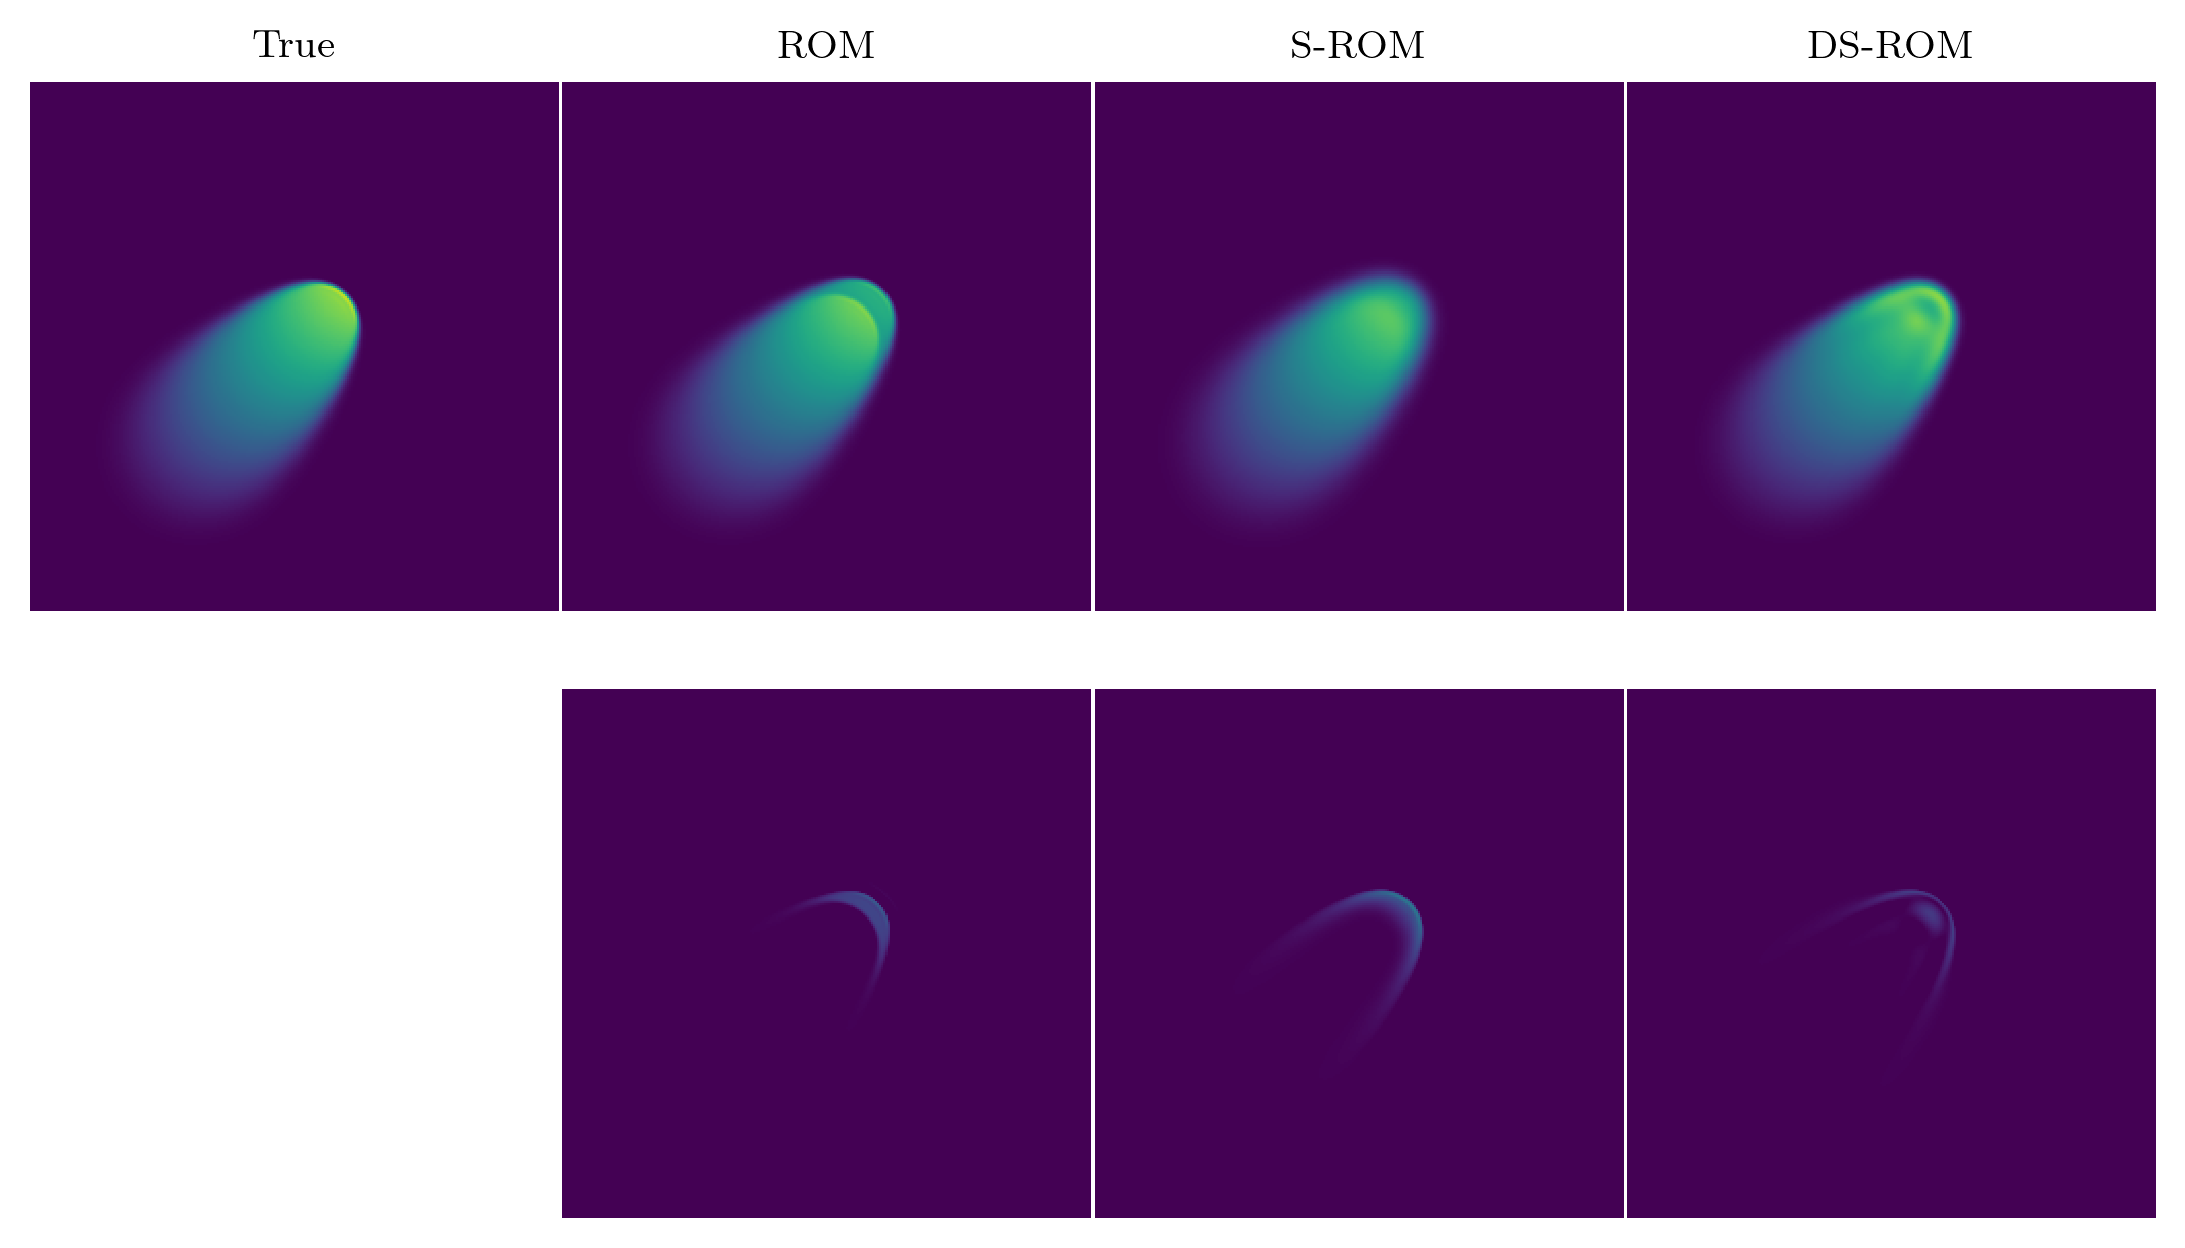

2 0.036944488261826364 0.036818705779324896 0.036818705779324896 -35.45663152772006


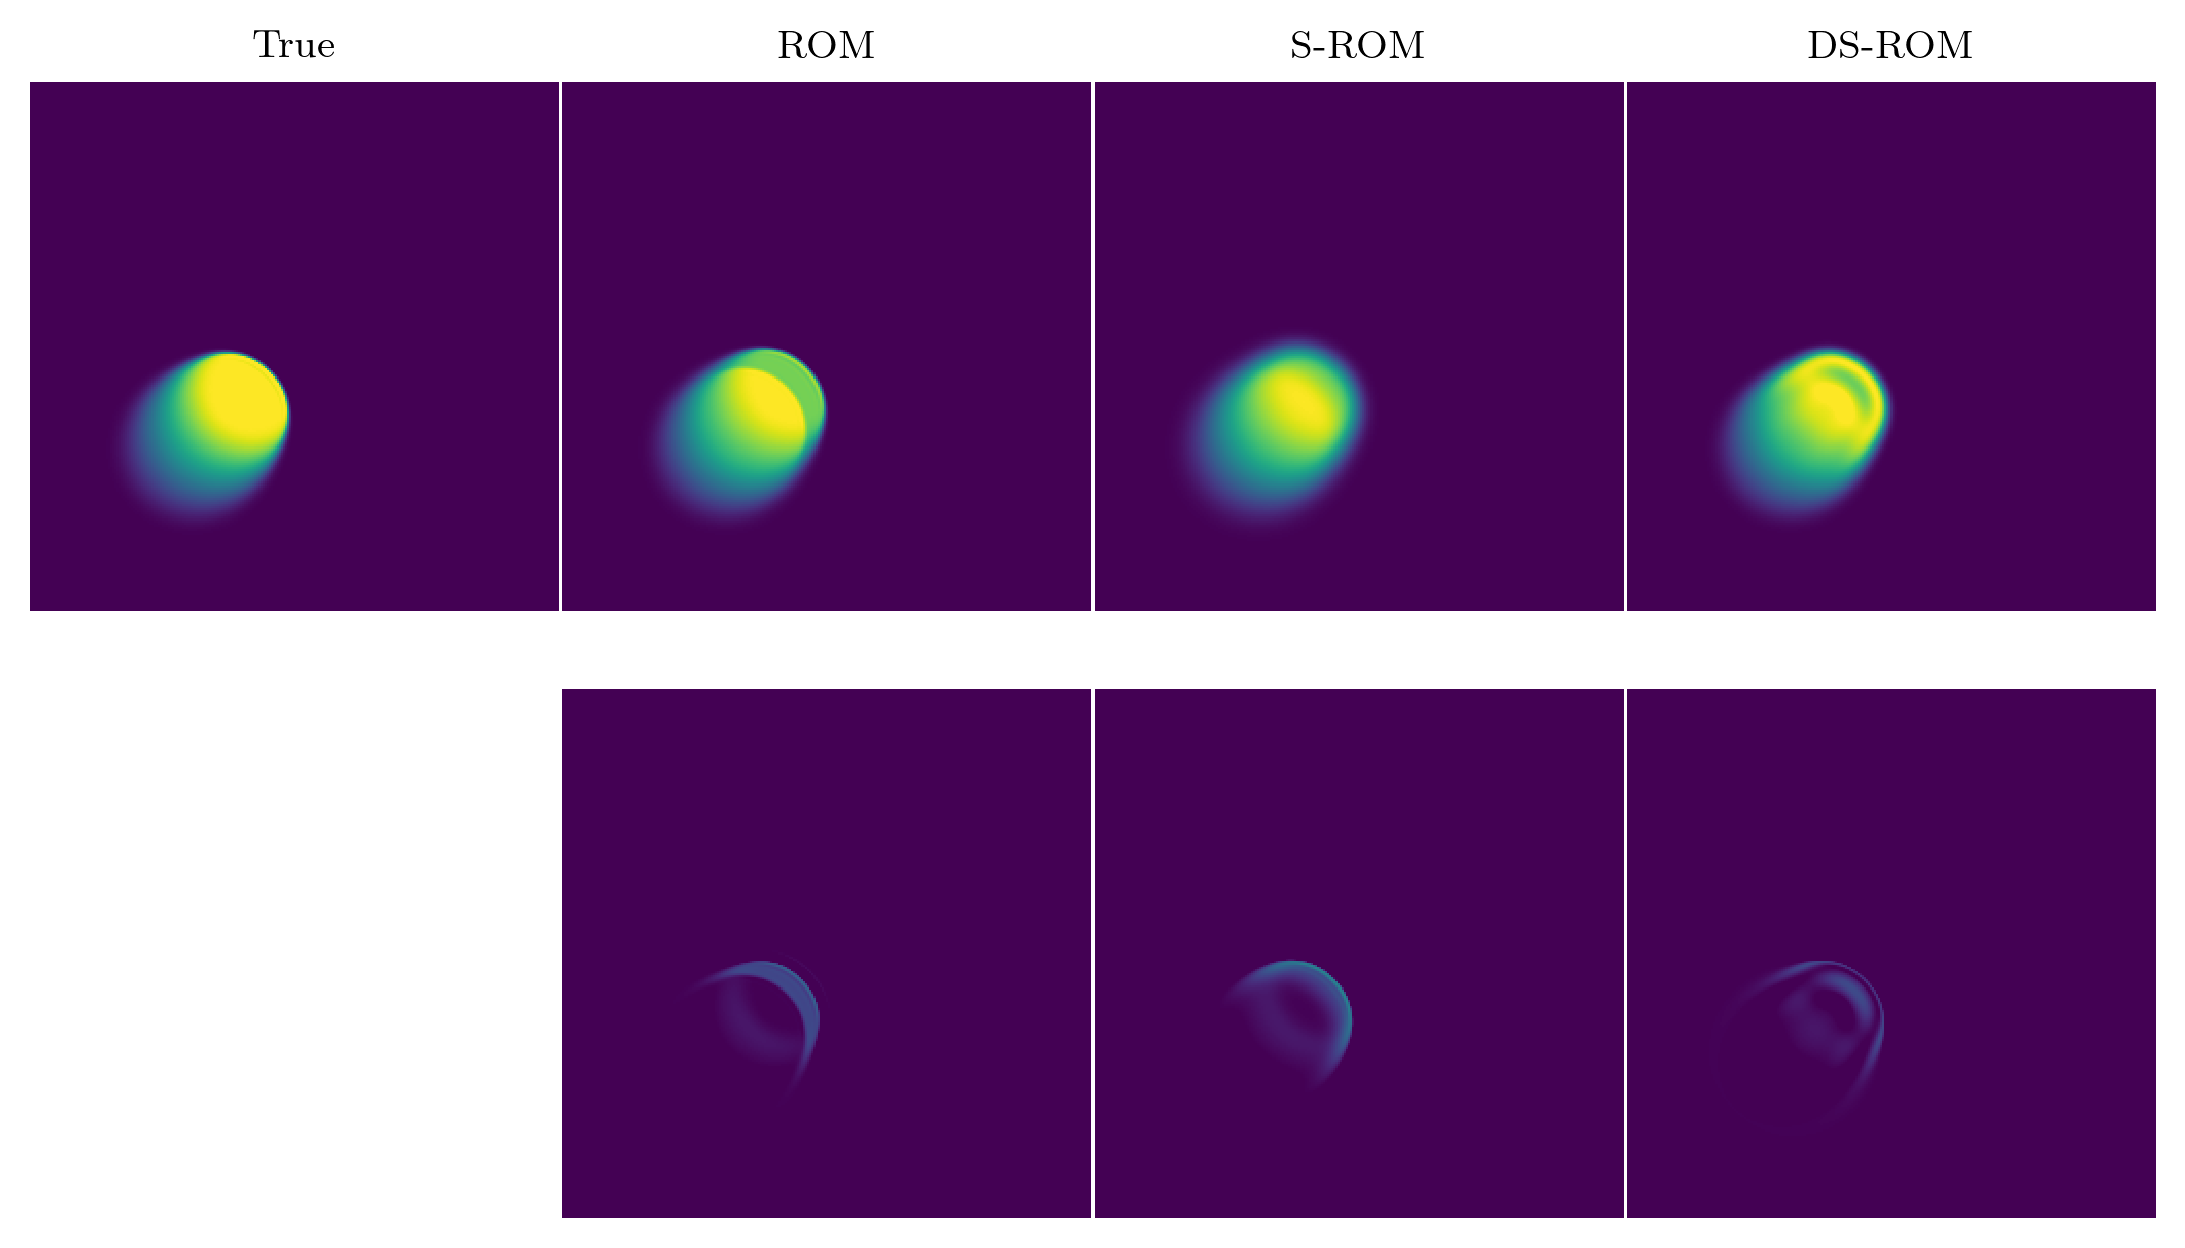

In [8]:
for i in [8, 2]:
    print(i, e_ROM[i], e_sROM[i], e_sROM[i], 100 * e_sROMs[i] / e_ROM[i] - 100)
    fig, axs = plt.subplots(2, 4,  figsize=(single_column_in*2, single_column_in*2/1.618))
    for col, (Z, title) in enumerate([
        (X_test[i], "True"),
        (X_test_ROM[i], "ROM"),
        (X_test_sROM[i], "S-ROM"),
        (X_test_sROMs[i], "DS-ROM"),
    ]):
        ax = axs[0, col]
        ax.pcolormesh(X_mesh, Y_mesh, Z.reshape(shape), vmin=0, vmax=1, shading="nearest", rasterized=True)
        ax.set_aspect("equal")
        ax.set_title(title)
        ax.set_axis_off()
        
        ax = axs[1, col]
        ax.set_aspect("equal")
        ax.set_axis_off()
        if col != 0:
            ax.pcolormesh(X_mesh, Y_mesh, (X_test[i]-Z).reshape(shape), vmin=0, vmax=1, shading="nearest", rasterized=True)
    plt.tight_layout(pad=0.0, w_pad=0.1, h_pad=0.1)
    pth = "../Plots/Burgers2D_ss"+str(i)
    plt.savefig(pth+"_results.pdf")
    plt.show()

## Optimization (sigma, sigmaD)

In [9]:
use_mu_adaptive_rule = True
ranks = [10, 20, 30, 50, 100]
params_opt = [[None] for i in range(len(ranks))]
for i, rank in enumerate(ranks):
    #for num_iter in [10, 20, 30, 50, 75, 100]:
        num_iter = 20
        X_train, mu_train, X_val, mu_val, X_test, mu_test = split_train_test_val(X_val_all, mu_val_all, rank)

        X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
        u_max = np.interp(mu_test, mu_train.ravel(), X_train.max(axis=1)).ravel()

        #print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
        print(X_train.shape, X_test.shape, X_val.shape)
        print(mu_train.shape, mu_test.shape, mu_val.shape)
        
        #rank = len(mu_train)
       # print(rank, 2 * sigma_opt)
        case["sigmaD"] = np.ones_like(mu_test.ravel())
        def _target1(params):
            case["c"] = False
            case["mu_train"] = mu_train
            case["sigma"], case["sigmaD"][:] = params[0], params[1]
            return target_function(case, X_train_gpu, mu_test, u_max, X_e=X_test)[2]

        def _target2(params):
            case["sigmaD"] = "calc_based_on_distance"
            case["mu_train"] = mu_train
            case["sigma"], case["c"] = params[0], params[1]
            return target_function(case, X_train_gpu, mu_test, u_max, X_e=X_test)[2]
        
        def _target3(params):
            case["mu_train"] = mu_train
            case["sigma"], case["c"], case["num_iter"] = params[0], params[1], int(round(params[2]))
            return target_function(case, X_train_gpu, mu_test, u_max, X_e=X_test)[2]
        sigma_opt = 0.23/rank
        bounds1 = Bounds([0.001, 0.001], [2 * sigma_opt, 3 * sigma_opt])
        bounds2 = Bounds([0.001, 0], [2 * sigma_opt, 3])

        case["num_iter"] = num_iter

        if use_mu_adaptive_rule:
            tartget=_target2
            bounds = bounds2
            case["c"] = 1.0
            case["sigmaD"] = "calc_based_on_distance"
        else:
            tartget=_target1
            bounds = bounds1
            case["c"] = False
            case["sigmaD"] = np.ones_like(mu_test.ravel())

        res = direct(_target, bounds, eps=1e-2, len_tol=0.01)
        _target(res["x"])
        params_opt[i] = res["x"]
        print("DIRECT result:", res["x"], "mean_sROMs (min) =", res["fun"])
    
        #bounds3 = ([0.001, 0, 1], [5 * sigma_opt, 5, 200])
        #res = direct(_target2, bounds2, eps=1e-2, len_tol=0.01)

print(params_opt)

(10, 1) (10, 66049) [0.  0.9]
(10, 66049) (20, 66049) (901, 66049)
(10, 1) (20, 1) (901, 1)
10 20 0.0235 False 0.034999999999999996 20 0.02448297424782154 0.033554957350761506 0.04230665857821407 0.769842 72.80032299171518
10 20 0.0385 False 0.034999999999999996 20 0.02448297424782154 0.046127869026669224 0.02838310565210775 0.604752 15.929973886376317
10 20 0.0085 False 0.034999999999999996 20 0.02448297424782154 0.02316679462674953 0.062143182772105524 0.642504 153.82203217256148
10 20 0.0235 False 0.057666666666666665 20 0.02448297424782154 0.033554957350761506 0.07569272916849501 0.913772 209.16476242762883
10 20 0.0235 False 0.012333333333333335 20 0.02448297424782154 0.033554957350761506 0.030654805017458413 0.636425 25.208664221774583
10 20 0.0385 False 0.057666666666666665 20 0.02448297424782154 0.046127869026669224 0.05905560035166958 0.873143 141.21089110292337
10 20 0.0385 False 0.012333333333333335 20 0.02448297424782154 0.046127869026669224 0.044448207997283676 0.467171 81

In [10]:
#params_opt = [[0.02016667, 0.35185185], [0.01145679, 0.5       ], [0.00846159, 0.53703704], [0.00628107, 0.35185185],  [0.00459259, 0.14197531] ]  # n_iter = 50?

# testing

(10, 1) (10, 66049) [0.  0.9]
(10, 66049) (20, 66049) (901, 66049)
(10, 1) (20, 1) (901, 1)
10 901 0.017944444444444443 False 0.019888888888888893 20 0.025937242937674604 0.030792975527720406 0.023389675837602916 23.740769 -9.822042790721113
26.781837


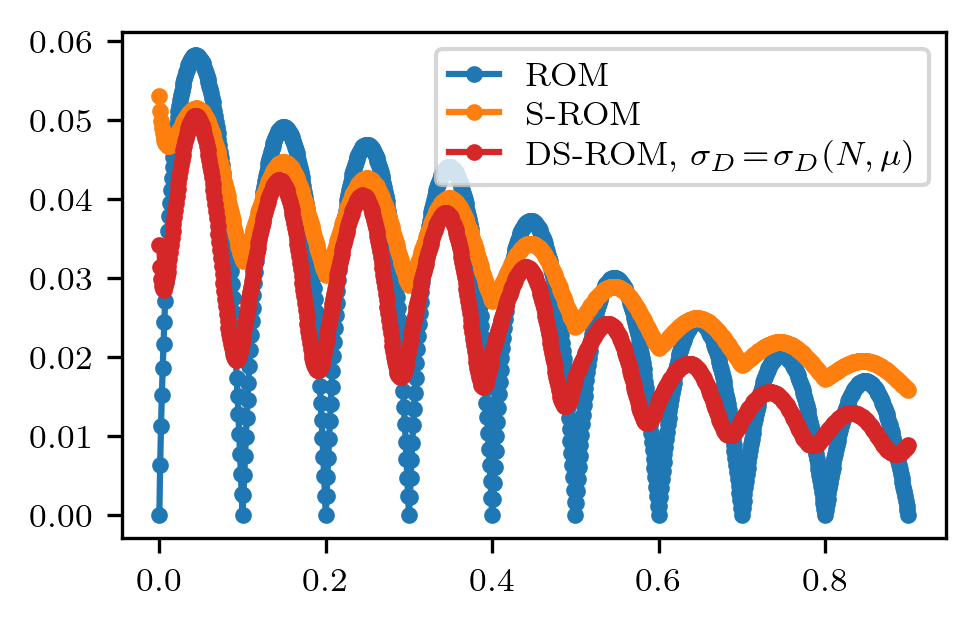

(20, 1) (20, 66049) [0.   0.95]
(20, 66049) (20, 66049) (951, 66049)
(20, 1) (20, 1) (951, 1)
20 951 0.010098765432098766 False 0.011546296296296298 20 0.014217327285570307 0.018362574537151784 0.012253752830313457 24.819258 -13.81113633959707
27.827914


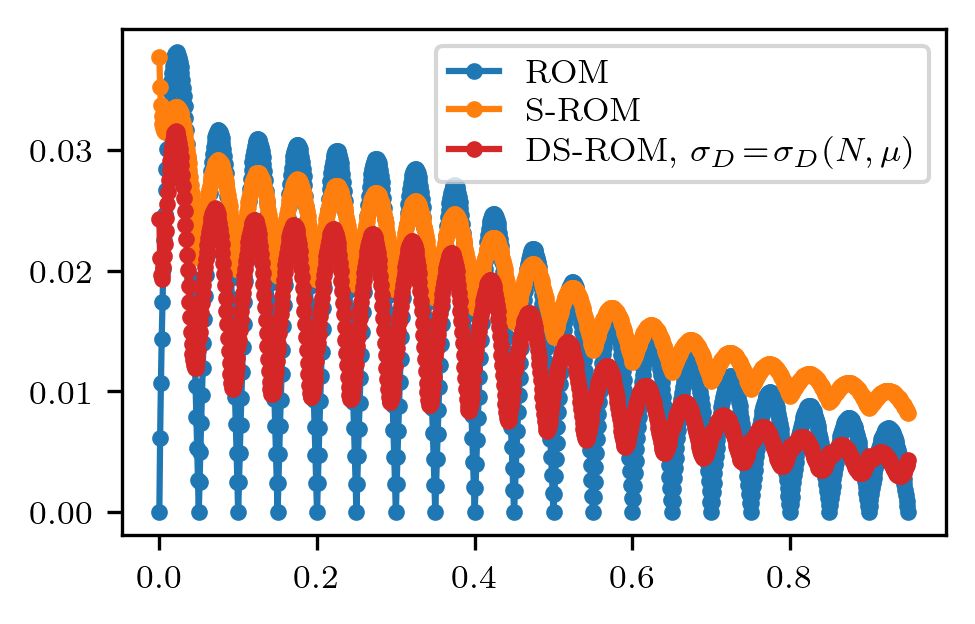

(30, 1) (30, 66049) [0.    0.986]
(30, 66049) (20, 66049) (987, 66049)
(30, 1) (20, 1) (987, 1)
30 987 0.007517832647462277 False 0.00874074074074074 20 0.009494617639834089 0.013498874876360294 0.007925517662916062 23.301206 -16.52620501888316
25.950743


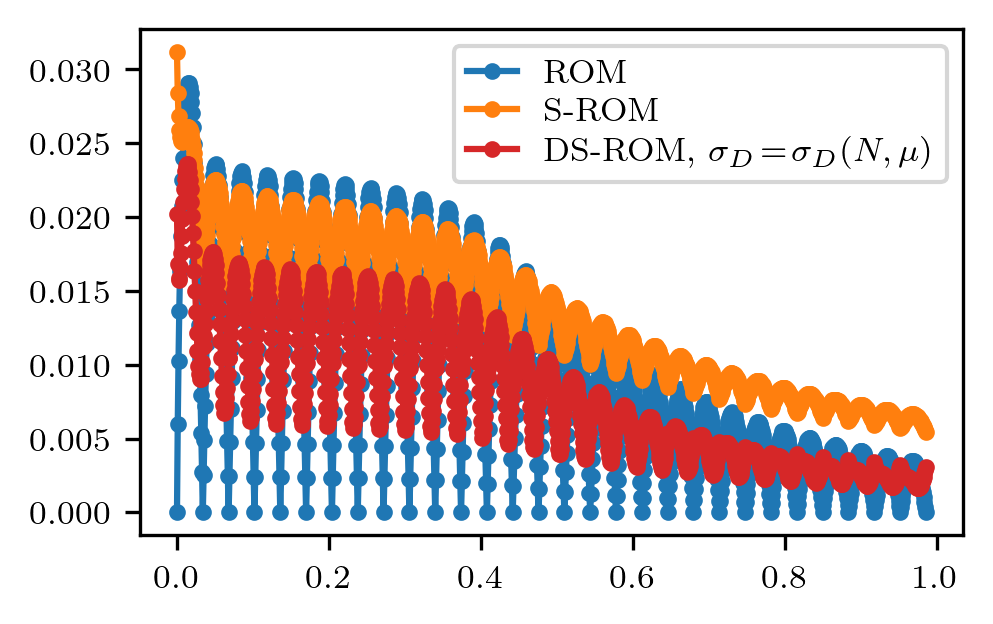

(50, 1) (50, 66049) [0.   0.98]
(50, 66049) (20, 66049) (981, 66049)
(50, 1) (20, 1) (981, 1)
50 981 0.005133744855967078 False 0.005714403292181069 20 0.004868774014685039 0.00879572255349016 0.0039703545919853025 23.730884 -18.452682749085355
26.688872


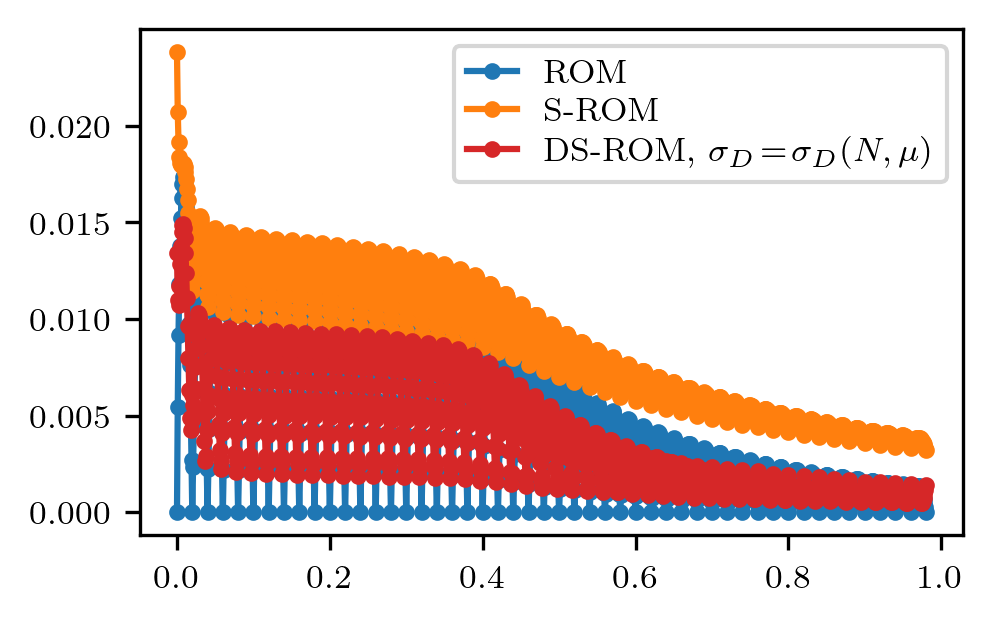

(100, 1) (100, 66049) [0.   0.99]
(100, 66049) (20, 66049) (991, 66049)
(100, 1) (20, 1) (991, 1)
100 991 0.004266666666666667 False 0.004556995884773662 20 0.0014871148575102914 0.00617381370877476 0.0013431546908072528 23.891696 -9.680500868914379
27.547893


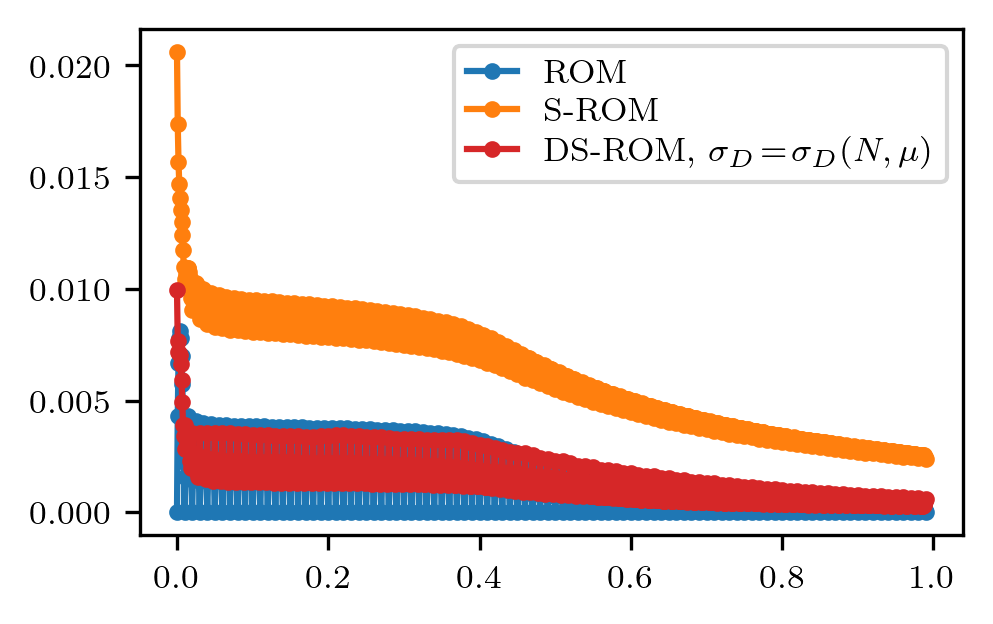

In [16]:
for i, rank in enumerate(ranks):
    X_train, mu_train, X_val, mu_val, X_test, mu_test = split_train_test_val(X_val_all, mu_val_all, rank)
    case["num_iter"] = 20
    if use_mu_adaptive_rule:
        case["sigma"], case["c"], case["sigmaD"] = params_opt[i][0], params_opt[i][1], "calc_based_on_distance"
    else:
        case["sigma"], case["c"], case["sigmaD"] = params_opt[i][0], False, np.ones_like(mu_val.ravel())*params_opt[i][1]
    
    X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    u_max = np.interp(mu_val, mu_train.ravel(), X_train.max(axis=1)).ravel()
    #print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
    print(X_train.shape, X_test.shape, X_val.shape)
    print(mu_train.shape, mu_test.shape, mu_val.shape)

    case["mu_train"] = mu_train
    t1 = datetime.now()
    mean_ROM, mean_sROM, mean_sROMs, X_val_ROM, X_val_sROM, X_val_sROMs = target_function(case, X_train_gpu, mu_val, u_max, X_e=X_val)
    t2 = datetime.now()
    print((t2-t1).total_seconds())
    e_ROM = L2_error_rw(X_val_ROM, X_val)
    e_sROM = L2_error_rw(X_val_sROM, X_val)
    e_sROMs = L2_error_rw(X_val_sROMs, X_val)
    fig, ax = plt.subplots()
    ax.plot(mu_val.ravel(), e_ROM.ravel(), "C0o-", ms=3, label=r"ROM")
    ax.plot(mu_val.ravel(), e_sROM.ravel(), "C1o-", ms=3, label=r"S-ROM")
    ax.plot(mu_val.ravel(), e_sROMs.ravel(), "C3o-", ms=3, label=r"DS-ROM, $\sigma_D\!=\!\sigma_D(N, \mu)$")  #  (\sigma_S, c)
    plt.legend()
    plt.show()

# DS-ROM + projection: best coefficients are assumed to be known

In [17]:
def target_function_best_coeff(case, X_train_gpu, mu_, u_max, X_e=None, X_eGPU=None):
    sgm = case["sigma"] / case["dx"]
    mode = case["mode"]
    shape = case["shape"]
    mu_train = case["mu_train"]
    sigma = case["sigma"]
    c = case["c"]
    x = case["x"]
    num_iter = case["num_iter"]
    
    print(len(mu_train), len(mu_), case["sigma"], case["c"], case["sigmaD"][0], case["num_iter"], end=" ")
    X_train_s = smoothen_GPU(X_train_gpu, shape, sgm, mode)
    #print(mu_train.shape, X_train.shape, X_train.shape)
    #U1, S, VT = np.linalg.svd(X_train.T, full_matrices=False)
    #U2, S, VT = np.linalg.svd(X_train_s.T, full_matrices=False)
    Q1, R1 = np.linalg.qr(X_train.T, mode="reduced")
    Q2, R2 = np.linalg.qr(X_train_s.T, mode="reduced")
    #G = X_train @ X_train.T                      # (n_snap, n_snap)
    #Ginv = np.linalg.pinv(G, rcond=rcond)
    #Gs = X_train_s @ X_train_s.T                      # (n_snap, n_snap)
    #Gsinv = np.linalg.pinv(Gs, rcond=rcond)

    # we assume we know the exact coefficients. here we compute them using the exact solution (U2.T @X_test_s.T)
    X_e_s = smoothen_GPU(X_eGPU, shape, sgm, mode)
    #X___ROM = (U1 @ (U1.T @X_e.T)).T
    #X___sROM = (U2 @ (U2.T @X_e_s.T)).T
    X___ROM = (Q1 @ (Q1.T @X_e.T)).T
    X___sROM = (Q2 @ (Q2.T @X_e_s.T)).T
    # X___ROM = (X_e @ X_train.T) @ Ginv @ X_train
    # X___sROM = (X_e_s @ X_train_s.T) @ Gsinv @ X_train_s
    
    #my_ROM = train_ROM_rw(mu_train, X_train)
    #my_sROM = train_ROM_rw(mu_train, X_train_s)
    #X___ROM = my_ROM.predict(mu_).snapshots_matrix
    #print(mu_.shape, mu_train.shape, X_train.shape)
    #u_max = np.ones_like(mu_).ravel()*np.max(X_train)

    cmax = u_max
    sigmaD = case["sigmaD"]
    #deconvolved = np.empty_like(X___sROM)
    deconvolved_gpu = cp.empty(X___sROM.shape)
    # Transfer all data to GPU once
    data_gpu = cp.asarray(X___sROM.astype(np.float32))
    t1 = datetime.now()

    if isinstance(sigmaD, np.ndarray):
        sgm_est = sigmaD
    elif sigmaD == "calc_based_on_distance":
        sgm_est = get_sigma_batch(sigma, mu_, mu_train, c=c)
    else:
        raise ValueError("unknown method for sigmaD.")
    for j in range(len(mu_)):
        # if isinstance(sigmaD, np.ndarray):
        #     sgm_est = sigmaD[j]
        # elif sigmaD == "calc_based_on_distance":
        #     sgm_est = get_sigma(sigma, mu_[j][None, ...], mu_train, c=c)
        # else:
        #     raise ValueError("unknown method for sigmaD.")
        res = richardson_lucy2_gpu(x, data_gpu[j].reshape(shape), sgm_est[j], num_iter, mode=mode, clip_max=cmax[j])[0].reshape(deconvolved_gpu[j].shape)
        deconvolved_gpu[j] = res
    t2 = datetime.now()
    X___sROMs = cp.asnumpy(deconvolved_gpu)
    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_e, X___ROM, X___sROM, X___sROMs, norm=L2_error_rw, scaler=False
    )
    print(mean_ROM, mean_sROM, mean_sROMs, (t2-t1).total_seconds(), improvement)
    return mean_ROM, mean_sROM, mean_sROMs, X___ROM, X___sROM, X___sROMs

In [18]:
ranks = [10, 20, 30, 50, 100]
case["num_iter"] = num_iter = 20
params_opt_best_coeff = [[None] for i in range(len(ranks))]
for i, rank in enumerate(ranks):
    X_train, mu_train, X_val, mu_val, X_test, mu_test = split_train_test_val(X_val_all, mu_val_all, rank)

    X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    X_test_gpu = cp.asarray(X_test.reshape(-1, *shape).astype(np.float32))
    
    u_max = np.interp(mu_test, mu_train.ravel(), X_train.max(axis=1)).ravel()


    case["sigmaD"] = np.ones_like(mu_test.ravel())
    def _target1(params):
        case["c"] = False
        case["mu_train"] = mu_train
        case["sigma"], case["sigmaD"][:] = params[0], params[1]
        return target_function_best_coeff(case, X_train_gpu, mu_test, u_max, X_e=X_test, X_eGPU=X_test_gpu)[2]

    def _target2(params):
        case["mu_train"] = mu_train
        case["sigma"], case["c"] = params[0], params[1]
        return target_function_best_coeff(case, X_train_gpu, mu_test, u_max, X_e=X_test, X_eGPU=X_test_gpu)[2]

    sigma_opt = 0.23/rank
    bounds1 = Bounds([0.001, 0.001], [2 * sigma_opt, 3 * sigma_opt])
    bounds2 = Bounds([0.001, 0], [2 * sigma_opt, 3])

    if use_mu_adaptive_rule:
        tartget=_target2
        bounds = bounds2
        case["c"] = 1.0
        case["sigmaD"] = "calc_based_on_distance"
    else:
        tartget=_target1
        bounds = bounds1
        case["c"] = False
        case["sigmaD"] = np.ones_like(mu_test.ravel())
    
    #bounds = Bounds([0.001, 0, 1], [5 * sigma_opt, 5, 200])
    case["num_iter"] = num_iter
    res = direct(_target, bounds, eps=1e-2, len_tol=0.01)
    params_opt_best_coeff[i] = res["x"]
    _target1(res["x"])
    print("DIRECT result:", res["x"], "mean_sROMs (min) =", res["fun"])
print(params_opt_best_coeff)

(10, 1) (10, 66049) [0.  0.9]
10 20 0.0235 False 0.034999999999999996 20 0.024023781330431836 0.031009442079630307 0.044494271122546857 0.87825 85.20927455406147
10 20 0.0385 False 0.034999999999999996 20 0.024023781330431836 0.04448385080306389 0.025771396298064998 0.583586 7.274520790860649
10 20 0.0085 False 0.034999999999999996 20 0.024023781330431836 0.021201919055849647 0.06386051183305207 0.609996 165.82206587169327
10 20 0.0235 False 0.057666666666666665 20 0.024023781330431836 0.031009442079630307 0.07620536649785763 0.836299 217.2080425212887
10 20 0.0235 False 0.012333333333333335 20 0.024023781330431836 0.031009442079630307 0.02956260378715726 0.450655 23.055581386387274
10 20 0.0385 False 0.057666666666666665 20 0.024023781330431836 0.04448385080306389 0.05977201542983981 0.805167 148.8035276699939
10 20 0.0385 False 0.012333333333333335 20 0.024023781330431836 0.04448385080306389 0.04269143799537716 0.516149 77.70490585217863
10 20 0.0085 False 0.057666666666666665 20 0.0

## testing



In [19]:
#params_opt_best_coeff = [np.array([0.01664815, 0.00617284]), np.array([0.0101893 , 0.00617284]), np.array([0.00781276, 0.0308642 ]), np.array([0.00520123, 0.00617284]), np.array([0.00106667, 0.08024691])]

(10, 1) (10, 66049) [0.  0.9]
10 901 0.017944444444444443 False 0.017370370370370373 20 0.025564767546742424 0.028295067261129566 0.016022725246040866 23.43193 -37.324971890532396
27.076525


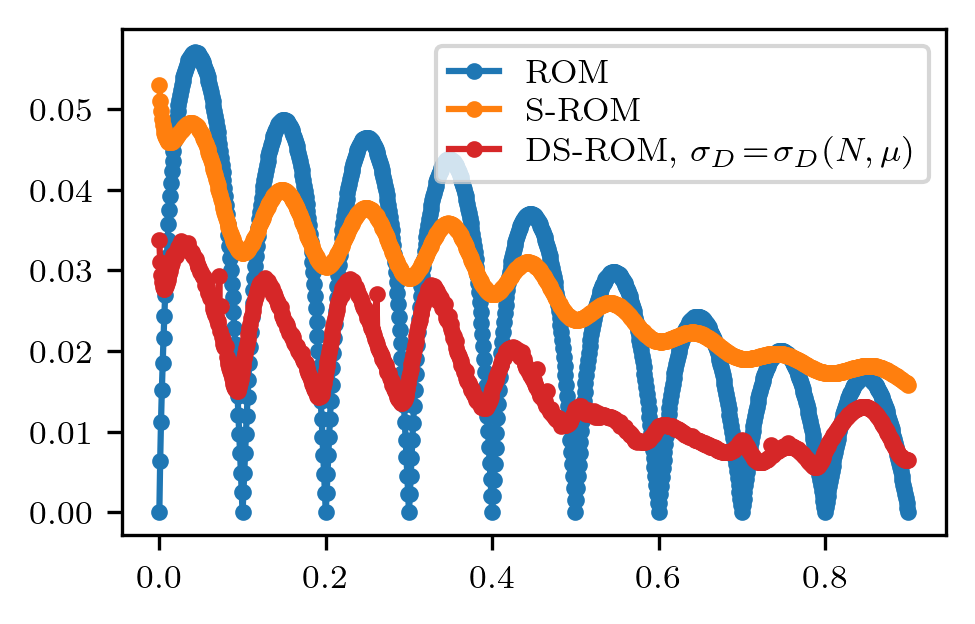

(20, 1) (20, 66049) [0.   0.95]
20 951 0.010460905349794238 False 0.010305555555555557 20 0.013827741791782028 0.0168728439523576 0.006931506751527177 23.842818 -49.87246033443694
27.579389


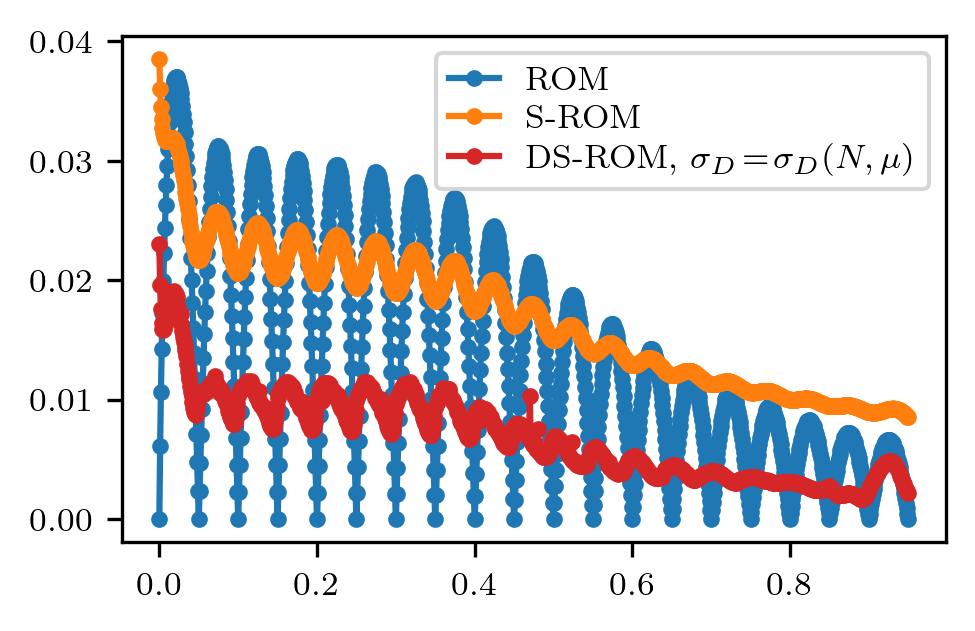

(30, 1) (30, 66049) [0.    0.986]
30 987 0.007989711934156379 False 0.007925925925925927 20 0.008997889284253808 0.01247983151154621 0.004120050045885205 25.327147 -54.21092752168845
29.234956


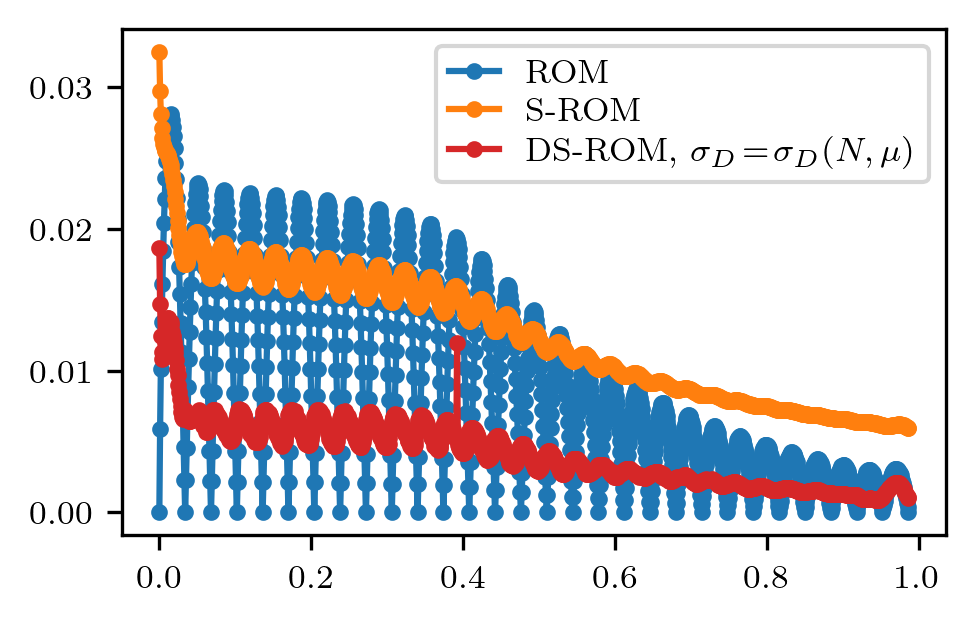

(50, 1) (50, 66049) [0.   0.98]
50 981 0.005234979423868313 False 0.005134979423868312 20 0.004094552246891299 0.007682634508587872 0.0019283181680670722 24.178514 -52.90527384206401
28.835359


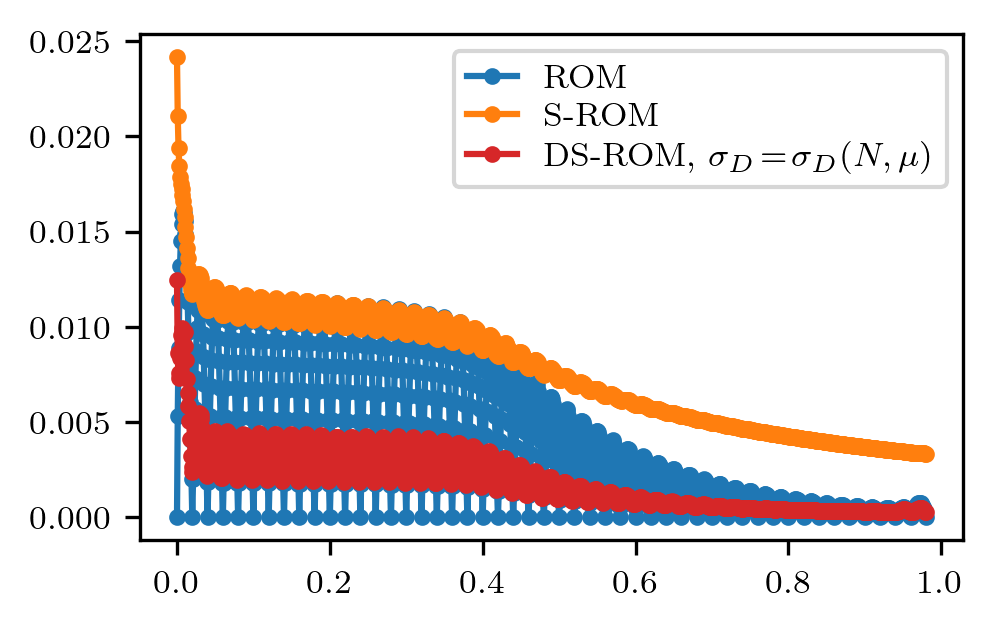

(100, 1) (100, 66049) [0.   0.99]
100 991 0.0012296296296296298 False 0.0011092592592592595 20 0.00028025527628466244 0.00031080092389110746 0.0005371111657545114 24.489504 91.65068821361061
30.737294


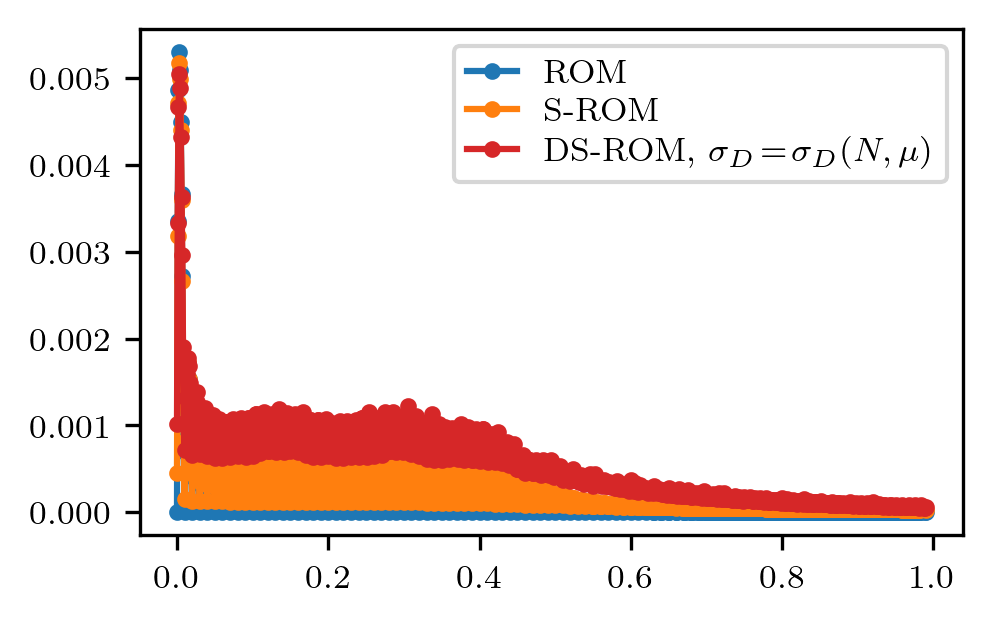

In [21]:

for i, rank in enumerate(ranks):
    X_train, mu_train, X_val, mu_val, X_test, mu_test = split_train_test_val(X_val_all, mu_val_all, rank)
    case["sigma"], case["c"], case["sigmaD"] = params_opt_best_coeff[i][0], params_opt_best_coeff[i][1], "calc_based_on_distance"
    case["sigma"], case["c"], case["sigmaD"] = params_opt_best_coeff[i][0], False, np.ones_like(mu_val.ravel())*params_opt_best_coeff[i][1]
    case["num_iter"] = 20
    case["mu_train"] = mu_train
    u_max = np.interp(mu_val, mu_train.ravel(), X_train.max(axis=1)).ravel()
    X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    X_test_gpu = cp.asarray(X_test.reshape(-1, *shape).astype(np.float32))
    X_val_gpu = cp.asarray(X_val.reshape(-1, *shape).astype(np.float32))

    t1 = datetime.now()
    mean_ROM, mean_sROM, mean_sROMs, X_val_ROM, X_val_sROM, X_val_sROMs = target_function_best_coeff(case, X_train_gpu, mu_val, u_max, X_e=X_val, X_eGPU=X_val_gpu)
    t2 = datetime.now()
    print((t2-t1).total_seconds())
    e_ROM = L2_error_rw(X_val_ROM, X_val)
    e_sROM = L2_error_rw(X_val_sROM, X_val)
    e_sROMs = L2_error_rw(X_val_sROMs, X_val)
    fig, ax = plt.subplots()
    ax.plot(mu_val.ravel(), e_ROM.ravel(), "C0o-", ms=3, label=r"ROM")
    ax.plot(mu_val.ravel(), e_sROM.ravel(), "C1o-", ms=3, label=r"S-ROM")
    ax.plot(mu_val.ravel(), e_sROMs.ravel(), "C3o-", ms=3, label=r"DS-ROM, $\sigma_D\!=\!\sigma_D(N, \mu)$")  #  (\sigma_S, c)
    plt.legend()
    plt.show()